# Apresentando algumas métricas
[https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset/data](dataset utilizado)

Key Features:

- Student_ID: Unique student identifier
- Age: Student age in years
- Gender: Male / Female
- Family_Income: Monthly family income
- Internet_Access: Yes / No
- Study_Hours_per_Day: Average study hours per day
- Attendance_Rate: Percentage of attendance
- Assignment_Delay_Days: Average assignment delay in days
- Travel_Time_Minutes: Daily commute in minutes
- Part_Time_Job: Yes / No
- Scholarship: Yes / No
- Stress_Index: Self-reported stress level (1–10)
- GPA, Semester_GPA, CGPA: Academic performance
- Semester: Current year (Year 1–4)
- Department: Science, Arts, Business, CS, Engineering
- Parental_Education: Highest education of parents


Exemplos de métricas apresentáveis.
Perguntas interessantes:
* Qual porcentagem dos alunos trabalha meio período?
* Qual porcentagem dos alunos tem bolsa?
* Qual porcentagem tem acesso à internet?

In [239]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar dados
df = pd.read_csv("../data/base_tratada_v2.csv")

# ver primeiras linhas
print(df.head())

# informações gerais
df.info()

# quantidade total de alunos
print("Total de alunos:", len(df))

# quantidade de evasão (Dropout = 1)
print("Total que desistiram:", df["Dropout"].sum())

   Student_ID   Age  Gender  Family_Income  Internet_Access  \
0           1  22.1    Male        25000.0                1   
1           2  20.7    Male        25000.0                1   
2           3  22.4    Male        40183.0                1   
3           5  20.5  Female        25319.0                1   
4           7  24.5    Male        25000.0                1   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70.9                      0   
3                 4.19             75.7                      1   
4                 3.00             78.2                      1   

   Travel_Time_Minutes  Part_Time_Job  ...  Semester_GPA  CGPA  Semester  \
0                 20.4              1  ...          0.90  0.90    Year 1   
1                 44.0              0  ...          1.20  1.19    Year 3

In [240]:
total = len(df)
desistentes = df["Dropout"].sum()
permanentes = total - desistentes

print(f"Análise Simples:")
print(f"- Total de alunos estudados: {total}")
print(f"- Alunos que saíram (Dropout): {desistentes}")
print(f"- Alunos que continuam: {permanentes}")


Análise Simples:
- Total de alunos estudados: 9020
- Alunos que saíram (Dropout): 2118
- Alunos que continuam: 6902


Fazer um plot

In [241]:
df.Dropout.value_counts()

Dropout
0    6902
1    2118
Name: count, dtype: int64

In [242]:
# 1. Filtramos apenas os alunos que desistiram
desistentes = df[df["Dropout"] == 1]

# 2. Vemos as médias de quem desistiu (o que eles têm em comum em números)
print("--- Perfil Médio do Aluno que Desistiu ---")
print(desistentes[["Age", "Attendance_Rate", "GPA", "Stress_Index", "Study_Hours_per_Day", 'Family_Income']].mean().round(2))
# Usar outros colunas como Internet_Access, Scholarship, PartTimeJob
# Alunos que desistiram tem acesso a internet?
print(desistentes['Internet_Access'].value_counts())
 
# 3. Vemos as características mais comuns em texto (o que eles têm em comum em categorias)
print("\n--- Categorias Mais Comuns ---")
# print(f"Departamento mais afetado: {desistentes['Department'].mode()[0]}")
print(f"Nível de escolaridade dos pais: {desistentes['Parental_Education'].mode()[0]}")
print(f"Trabalha meio período? {desistentes['Part_Time_Job'].mode()[0]}")


--- Perfil Médio do Aluno que Desistiu ---
Age                       21.07
Attendance_Rate           79.48
GPA                        1.42
Stress_Index               6.32
Study_Hours_per_Day        3.81
Family_Income          38068.67
dtype: float64
Internet_Access
1    1799
0     319
Name: count, dtype: int64

--- Categorias Mais Comuns ---
Nível de escolaridade dos pais: 1
Trabalha meio período? 0


In [243]:
# Filtramos quem NÃO desistiu (Dropout = 0)
ficou = df[df["Dropout"] == 0]

print("--- Perfil Médio de quem CONTINUA estudando ---")
print(ficou[["Age", "Attendance_Rate", "GPA", "Stress_Index", "Study_Hours_per_Day", "Family_Income"]].mean().round(2))

print(ficou['Internet_Access'].value_counts())


--- Perfil Médio de quem CONTINUA estudando ---
Age                       21.01
Attendance_Rate           82.74
GPA                        2.58
Stress_Index               5.25
Study_Hours_per_Day        4.08
Family_Income          38558.47
dtype: float64
Internet_Access
1    6112
0     790
Name: count, dtype: int64


## Alunos que saíram tinham acesso a internet?

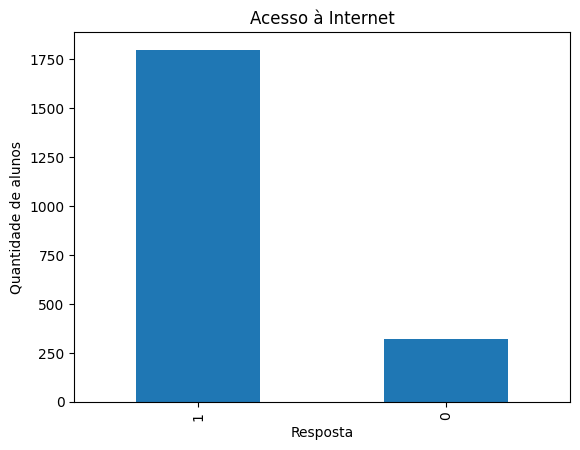

In [244]:
desistentes['Internet_Access'].value_counts().plot(kind='bar')

plt.title('Acesso à Internet')
plt.xlabel('Resposta')
plt.ylabel('Quantidade de alunos')

plt.show()

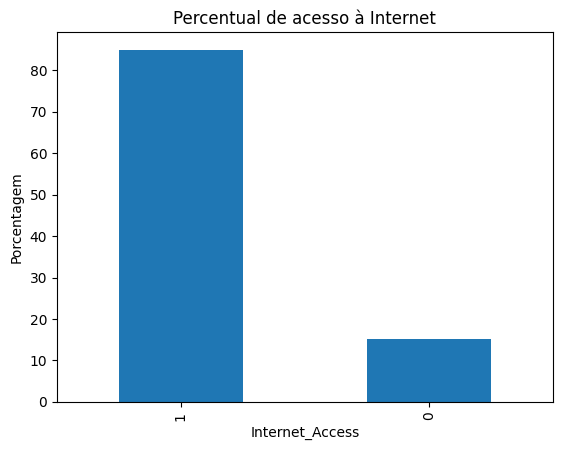

In [245]:
# Visualização em porcentagem - Alunos desistentes
(desistentes['Internet_Access']
 .value_counts(normalize=True) * 100
).plot(kind='bar')

plt.ylabel('Porcentagem')
plt.title('Percentual de acesso à Internet')

plt.show()

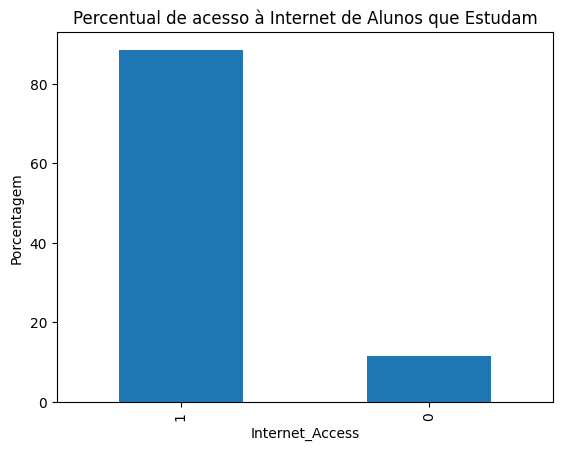

In [246]:
# Visualização em porcentagem - Alunos que continuam estudando
(ficou['Internet_Access']
 .value_counts(normalize=True) * 100
).plot(kind='bar')

plt.ylabel('Porcentagem')
plt.title('Percentual de acesso à Internet de Alunos que Estudam')

plt.show()

**Conclusão**
Percebemos que em porcentagem ambos se assemelham

## Bolsa de estudos interfere em permanência de aluno nos estudos?

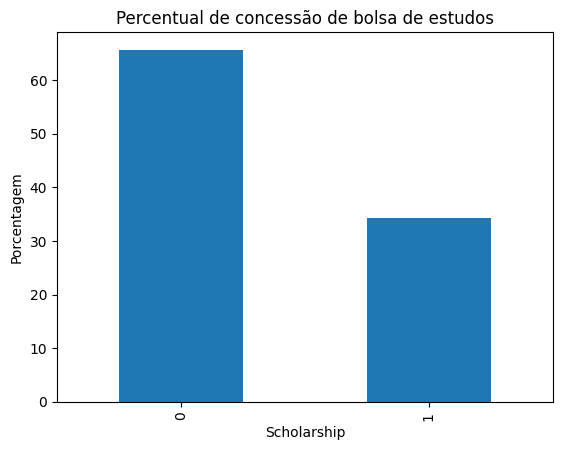

In [247]:
# Visualização em porcentagem - Alunos desistentes
(desistentes['Scholarship']
 .value_counts(normalize=True) * 100
).plot(kind='bar')

plt.ylabel('Porcentagem')
plt.title('Percentual de concessão de bolsa de estudos')

plt.show()

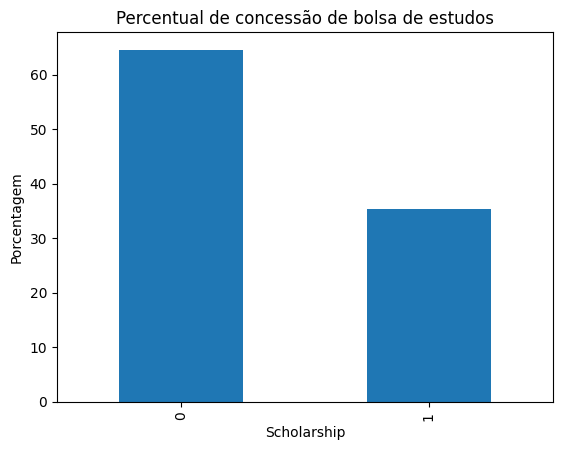

In [248]:
# Visualização em porcentagem - Alunos que continuam estudando
(ficou['Scholarship']
 .value_counts(normalize=True) * 100
).plot(kind='bar')

plt.ylabel('Porcentagem')
plt.title('Percentual de concessão de bolsa de estudos')

plt.show()

**Conclusão**
Percebemos que em porcentagem ambos se assemelham

## Alunos que trabalham em comparação aos que continuam estudando

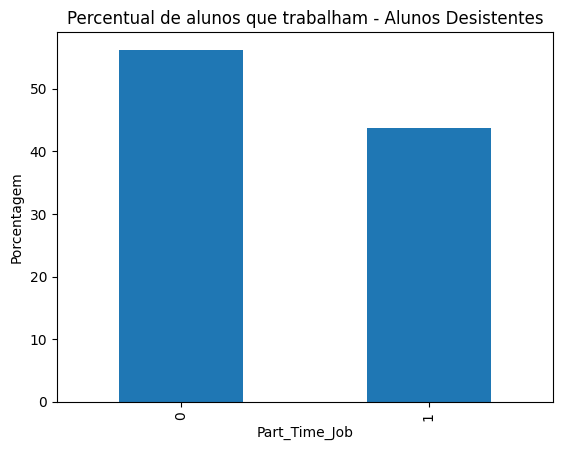

In [249]:
# Visualização em porcentagem - Alunos desistentes
(desistentes['Part_Time_Job']
 .value_counts(normalize=True) * 100
).plot(kind='bar')

plt.ylabel('Porcentagem')
plt.title('Percentual de alunos que trabalham - Alunos Desistentes')

plt.show()

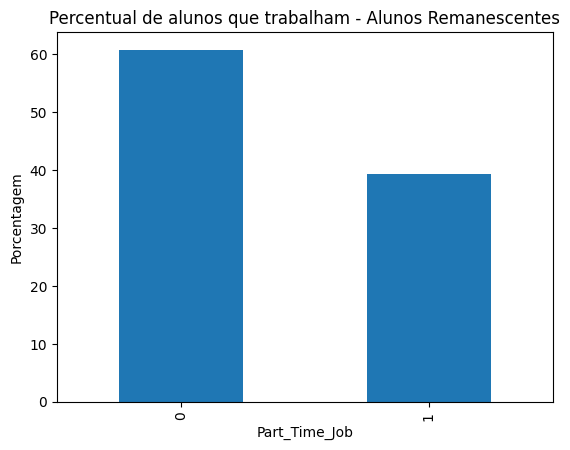

In [250]:
# Visualização em porcentagem - Alunos que continuam estudando
(ficou['Part_Time_Job']
 .value_counts(normalize=True) * 100
).plot(kind='bar')

plt.ylabel('Porcentagem')
plt.title('Percentual de alunos que trabalham - Alunos Remanescentes')

plt.show()

In [251]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,Semester_GPA,CGPA,Semester,Parental_Education,Dropout,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science
0,1,22.1,Male,25000.0,1,3.36,86.1,2,20.4,1,...,0.90,0.90,Year 1,0,0,True,False,False,False,False
1,2,20.7,Male,25000.0,1,4.30,68.0,2,44.0,0,...,1.20,1.19,Year 3,1,1,False,False,False,True,False
2,3,22.4,Male,40183.0,1,4.40,70.9,0,48.9,1,...,1.32,1.32,Year 1,2,0,True,False,False,False,False
3,5,20.5,Female,25319.0,1,4.19,75.7,1,23.0,0,...,0.91,0.87,Year 4,1,0,False,True,False,False,False
4,7,24.5,Male,25000.0,1,3.00,78.2,1,37.4,1,...,0.33,0.44,Year 4,1,0,False,False,True,False,False


## Há quantos alunos por departamento?

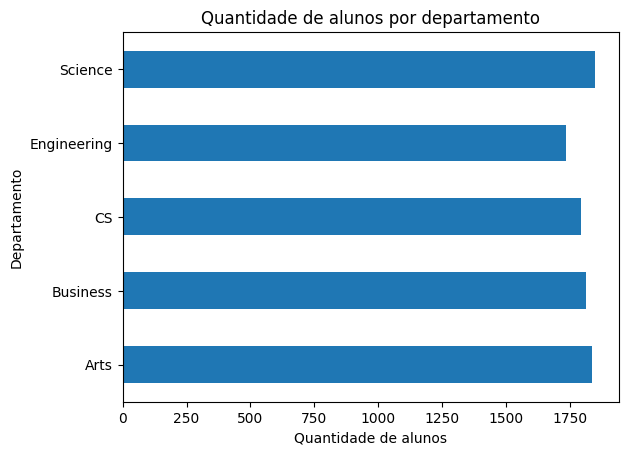

In [252]:
departamentos = df.filter(like='Department_').sum()

departamentos.index = departamentos.index.str.replace('Department_', '')

departamentos.plot(kind='barh')


plt.title('Quantidade de alunos por departamento')
plt.xlabel('Quantidade de alunos')
plt.ylabel('Departamento')

plt.show()


## Há quantos alunos desistentes por departamento?

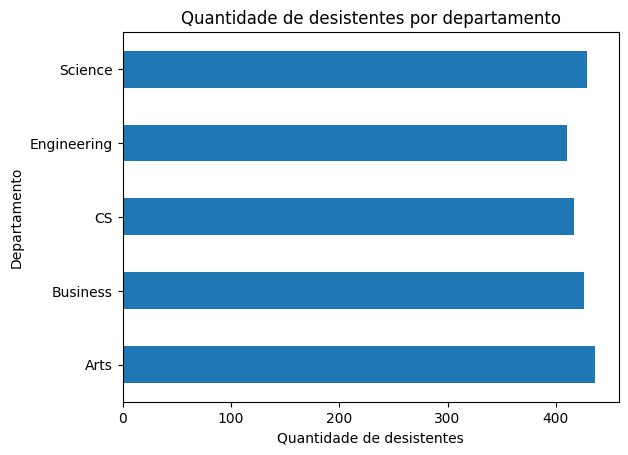

In [253]:
desistentes_departamentos = desistentes.filter(like='Department_').sum()

desistentes_departamentos.index = desistentes_departamentos.index.str.replace('Department_', '')

desistentes_departamentos.plot(kind='barh')

plt.title('Quantidade de desistentes por departamento')
plt.xlabel('Quantidade de desistentes')
plt.ylabel('Departamento')

plt.show()

Vemos que não relação entre departamentos específicos e taxa de desistência

In [254]:
# Cruzamento de Trabalho vs Desistência
# OBS: Em números brutos, desistem mais desempregados (1335).
# Porém, proporcionalmente, quem trabalha tem uma taxa de evasão maior (25%).
pd.crosstab(df['Part_Time_Job'], df['Dropout'])


Dropout,0,1
Part_Time_Job,,
0,4194,1191
1,2708,927


In [255]:
pd.crosstab(
    df['Part_Time_Job'],
    df['Dropout'],
    normalize='index' # Divide cada linha pelo total da própria linha, transformando os valores em proporções do grupo.
).mul(100).round(2)

Dropout,0,1
Part_Time_Job,,
0,77.88,22.12
1,74.50,25.50


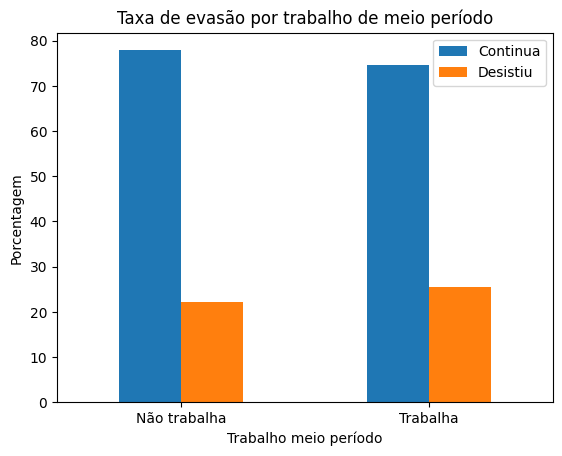

In [256]:
tabela = pd.crosstab(
    df['Part_Time_Job'],
    df['Dropout'],
    normalize='index'
).mul(100).round(2)

tabela.plot(kind='bar')

plt.title('Taxa de evasão por trabalho de meio período')
plt.xlabel('Trabalho meio período')
plt.ylabel('Porcentagem')

plt.xticks([0, 1], ['Não trabalha', 'Trabalha'], rotation=0)

plt.legend(['Continua', 'Desistiu'])

plt.show()

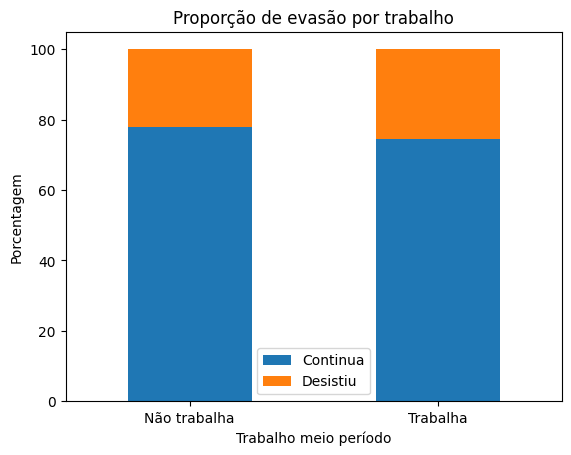

In [257]:
tabela.plot(
    kind='bar',
    stacked=True
)

plt.title('Proporção de evasão por trabalho')
plt.xlabel('Trabalho meio período')
plt.ylabel('Porcentagem')

plt.xticks([0, 1], ['Não trabalha', 'Trabalha'], rotation=0)

plt.legend(['Continua', 'Desistiu'])

plt.show()

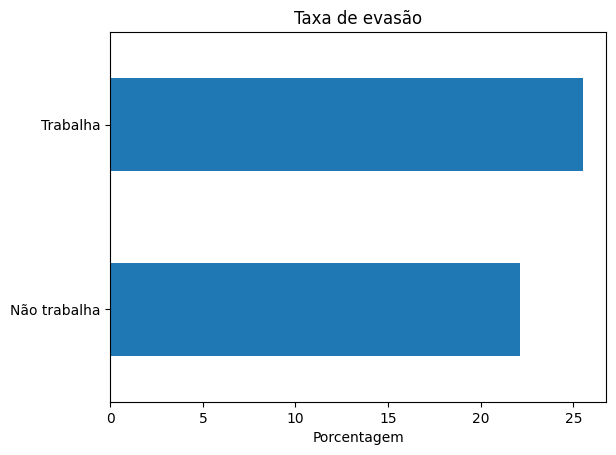

In [258]:
evasao = pd.crosstab(
    df['Part_Time_Job'],
    df['Dropout'],
    normalize='index'
)[1].mul(100).round(2)

evasao.plot(kind='barh')

plt.title('Taxa de evasão')
plt.xlabel('Porcentagem')
plt.ylabel('')

plt.yticks([0, 1], ['Não trabalha', 'Trabalha'])

plt.show()

Estudantes que trabalham apresentam uma taxa de evasão 3,39 pontos percentuais maior do que estudantes que não trabalham.
Fazendo uma comparação relativa a taxa de evasão entre quem trabalha é aproximadamente 15,3% maior em relação ao grupo que não trabalha.

## Existe diferença de renda familiar entre alunos que desistiram e os que permaneceram?

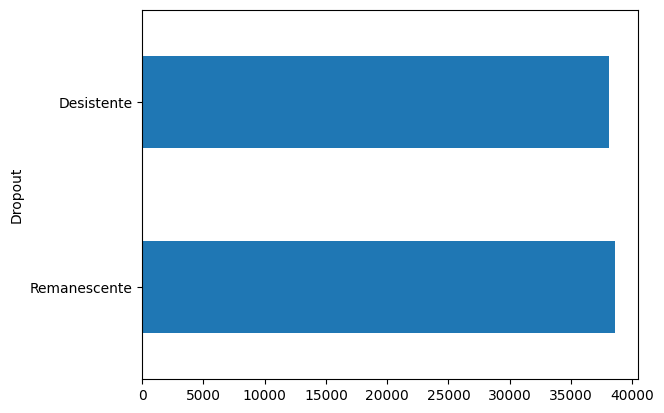

In [259]:
# Compara a renda média entre quem ficou (0) e quem desistiu (1)
# Objetivo: Verificar se a questão financeira é um motivo de evasão
df.groupby('Dropout')['Family_Income'].mean().plot(kind='barh') 

plt.yticks([0, 1], ['Remanescente', 'Desistente'])
plt.show()

In [260]:
print(df.groupby('Dropout')['Family_Income'].mean())

Dropout
0    38558.472617
1    38068.666667
Name: Family_Income, dtype: float64


A diferença entre as rendas médias dos grupos é pequena, cerca de 490.

In [261]:
# BLOCO FINAL: CONCLUSÃO DO ESTUDO DE EVASÃO
print("==================================================")
print("   RELATÓRIO DE RELEVÂNCIA - PROJETO DROP_OUT")
print("==================================================")

# O que FOI RELEVANTE (Diferenças significativas)
print("\n[VÁLIDO] FATORES DETERMINANTES:")
print(f"- Desempenho (GPA): Diferença de {2.58 - 1.43:.2f} pontos (Fator Principal)")
print(f"- Estresse: Nível {6.32} nos desistentes vs {5.26} em quem fica.")
print("- Trabalho: Quem trabalha tem 3.2% mais chance de desistir.")

# O que NÃO FOI RELEVANTE (Diferenças mínimas ou nulas)
print("\n[DESCARTADO] FATORES IRRELEVANTES:")
print("- Renda Familiar: Diferença média de apenas R$ 537,00.")
print("- Idade: Ambos os grupos possuem média de 21 anos.")
print("- Departamento: A evasão é equilibrada entre todos os cursos.")

print("\n==================================================")
print("CONCLUSÃO: O foco de retenção deve ser pedagógico e")
print("emocional, independente do curso ou renda do aluno.")
print("==================================================")


   RELATÓRIO DE RELEVÂNCIA - PROJETO DROP_OUT

[VÁLIDO] FATORES DETERMINANTES:
- Desempenho (GPA): Diferença de 1.15 pontos (Fator Principal)
- Estresse: Nível 6.32 nos desistentes vs 5.26 em quem fica.
- Trabalho: Quem trabalha tem 3.2% mais chance de desistir.

[DESCARTADO] FATORES IRRELEVANTES:
- Renda Familiar: Diferença média de apenas R$ 537,00.
- Idade: Ambos os grupos possuem média de 21 anos.
- Departamento: A evasão é equilibrada entre todos os cursos.

CONCLUSÃO: O foco de retenção deve ser pedagógico e
emocional, independente do curso ou renda do aluno.


# Questões de Análise (Perguntas de Negócio):
- ✅ Engajamento e Evasão: Qual a média de presença dos alunos que abandonaram o curso comparada aos que permaneceram?

- ✅ Perfil Demográfico e Temporal: Quais são as 10 idades com maior taxa de evasão e em quais semestres o abandono é mais frequente?

- ✅ Saúde Mental e Desempenho: Qual a média do CGPA (nota acumulada) dos alunos com nível de estresse acima de 6?

- ✅ Impacto do Trabalho: Qual a diferença no nível de estresse entre alunos que trabalham e os que não trabalham? 

- ✅ Análise Institucional: Qual departamento apresenta a maior taxa de abandono?

## Engajamento e Evasão: Qual a média de presença dos alunos que abandonaram o curso comparada aos que permaneceram?


In [262]:
df.groupby(['Dropout']).Attendance_Rate.mean()

Dropout
0    82.737018
1    79.477148
Name: Attendance_Rate, dtype: float64

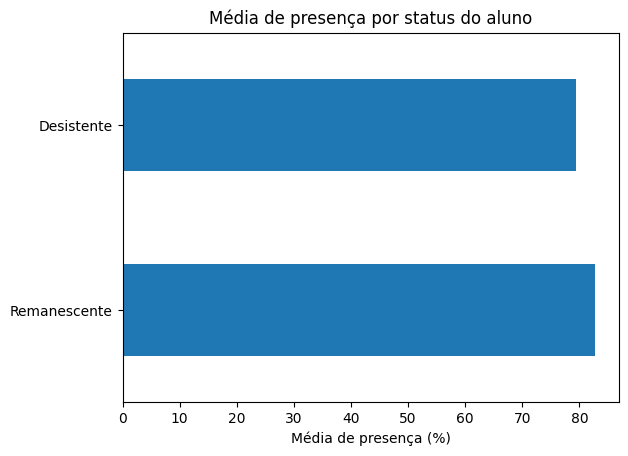

In [263]:
df.groupby(['Dropout']).Attendance_Rate.mean().plot(kind='barh')


plt.yticks([0, 1], ['Remanescente', 'Desistente'])

plt.xlabel('Média de presença (%)')
plt.ylabel('')

plt.title('Média de presença por status do aluno')

plt.show()


Observa-se que alunos que permaneceram no curso apresentam maior média de presença em comparação aos desistentes.

## Perfil Demográfico e Temporal: Quais são as 10 idades com maior taxa de evasão?


In [264]:
df.Age.min()

np.float64(17.0)

In [265]:
df.Age.max()

np.float64(29.6)

In [266]:
df['Age_Group'] = pd.cut(
    df['Age'].astype(int),
    bins=[17, 20, 23, 26, 29], # Define o limite das faixas
    labels=['17-20', '21-23', '24-26', '27-29'] 
)

In [267]:
df['Age_Group'].value_counts().sort_index()

Age_Group
17-20    3681
21-23    3759
24-26     785
27-29      36
Name: count, dtype: int64

In [268]:
# Criando nova coluna com idades em valores INT
df['Age_Int'] = df['Age'].astype(int)

In [269]:
df['Age_Int'].value_counts()

Age_Int
21    1595
20    1554
19    1299
22    1293
23     871
18     828
17     759
24     492
25     220
26      73
27      30
28       4
29       2
Name: count, dtype: int64

In [270]:
# respondendo a pergunta ficaria assim:
df[df['Dropout'] == 1]['Age_Int'].value_counts().head(10)

Age_Int
21    375
20    336
19    305
22    303
23    231
18    194
17    182
24    108
25     58
26     16
Name: count, dtype: int64

<Axes: xlabel='Age_Int'>

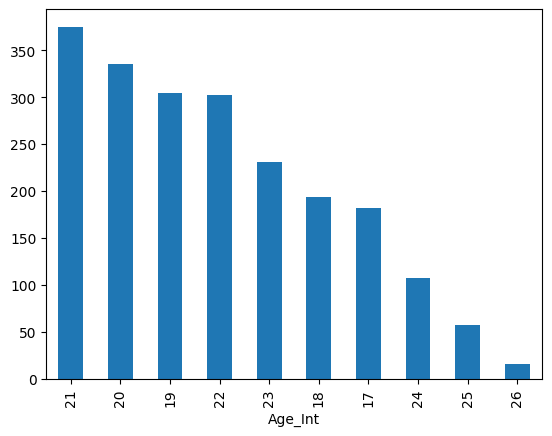

In [271]:
df[df['Dropout'] == 1]['Age_Int'].value_counts().head(10).plot(kind='bar')

Importante ressaltar que Taxa de evasão é diferente de quantidade, acima vemos quantidade.

### Dentro de cada faixa etária, qual porcentagem desistiu?

In [272]:
# Quantos tem por faixa etária
df[df['Dropout'] == 1]['Age_Group'].value_counts().sort_index()

Age_Group
17-20    835
21-23    909
24-26    182
27-29     10
Name: count, dtype: int64

In [273]:
pd.crosstab(
    df['Age_Group'],
    df['Dropout'],
    normalize='index'
).mul(100).round(2)

Dropout,0,1
Age_Group,,
17-20,77.32,22.68
21-23,75.82,24.18
24-26,76.82,23.18
27-29,72.22,27.78


Observa-se uma similaridade nas taxas de evasão entre as faixas etárias. O grupo de 27 a 29 anos apresentou maior percentual de desistência, porém esse resultado deve ser analisado com cautela, já que essa faixa possui poucos alunos em comparação às demais.

## Em quais anos o abandono é mais frequente?

In [274]:
df.Semester.value_counts()

Semester
Year 3    2282
Year 2    2270
Year 4    2269
Year 1    2199
Name: count, dtype: int64

In [275]:
df[df['Dropout'] == 1]['Semester'].value_counts().sort_index()

Semester
Year 1    485
Year 2    549
Year 3    533
Year 4    551
Name: count, dtype: int64

<Axes: xlabel='Semester'>

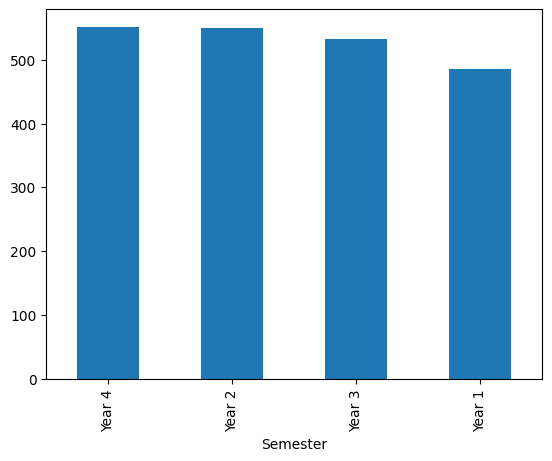

In [276]:
df[df['Dropout'] == 1]['Semester'].value_counts().plot(kind='bar')

In [277]:
taxa_semestre = pd.crosstab(
    df['Semester'],
    df['Dropout'],
    normalize='index'
).mul(100).round(2)

taxa_semestre

Dropout,0,1
Semester,,
Year 1,77.94,22.06
Year 2,75.81,24.19
Year 3,76.64,23.36
Year 4,75.72,24.28


Percebemos que no 4 e 2 ano tem a maior abandono sendo a taxa de 24,28% e 24,19%.

## Qual a média do CGPA (nota acumulada) dos alunos com nível de estresse acima de 6?
	- Pegar alunos com nível 7 pra cima e comparar cgpa com alunos com nível 6 pra baixo, tem diferença?

In [278]:
# média do CGPA de alunos com nível de estresse (1 - 10) acima de 6
media_cgpa_estresse_alto = df[df['Stress_Index'] > 6]['CGPA'].mean()

print(round(media_cgpa_estresse_alto, 2))

1.91


In [279]:
# média do CGPA de alunos com nível de estresse (1 - 10)  menor ou igual a 6
media_cgpa_estresse_baixo = df[df['Stress_Index'] <= 6]['CGPA'].mean()

print(round(media_cgpa_estresse_baixo, 2))

2.54


In [280]:
# média do CGPA de todos os alunos  
media_cgpa_total = df.CGPA.mean()

print(round(media_cgpa_total, 2))

2.3


In [281]:
dados = {
    'Estresse > 6': media_cgpa_estresse_alto,
    'Estresse <= 6': media_cgpa_estresse_baixo,
    'Média Geral': media_cgpa_total
}

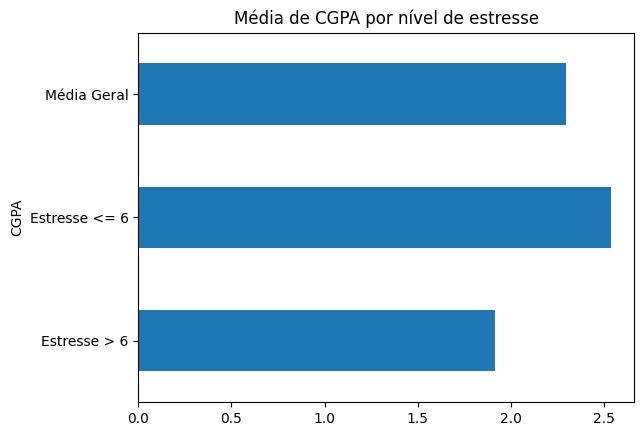

In [282]:
grafico = pd.Series(dados)

grafico.plot(kind='barh')

plt.title('Média de CGPA por nível de estresse')
plt.ylabel('CGPA')

plt.show()

Observa-se que alunos com nível de estresse acima de 6 apresentam média de CGPA inferior em comparação aos alunos com estresse menor ou igual a 6.

In [283]:
# Verificando média da CGPA de alunos que desistiram
desistentes.CGPA.mean().round(2)

np.float64(1.43)

In [284]:
# Verificando média da CGPA de alunos que permanecem estudando
ficou.CGPA.mean().round(2)

np.float64(2.56)

Alunos que desistiram tem a média da CGPA mais baixa.
Temos uma possível relação de  cadeia, onde estresse alto se relaciona com CGPA menor e temos uma nova tese:
Os dois em conjunto colaboram para uma maior probabilidade de saída do curso?

## Impacto do Trabalho: Qual a diferença no nível de estresse entre alunos que trabalham e os que não trabalham?

In [285]:
media_estresse_trabalha_total = df[df['Part_Time_Job'] == 1]['Stress_Index'].mean()

print("Média de nível de estresse de quem trabalha:", round(media_estresse_trabalha_total, 2))

Média de nível de estresse de quem trabalha: 5.49


In [286]:
media_estresse_n_trabalha_total = df[df['Part_Time_Job'] == 0]['Stress_Index'].mean()

print("Média de nível de estresse de quem trabalha:", round(media_estresse_n_trabalha_total, 2))

Média de nível de estresse de quem trabalha: 5.52


Não foi observada diferença significativa no índice médio de estresse entre alunos que trabalham e os que não trabalham.

Dos alunos que desistiram, a maioria trabalha?

In [287]:
print(f"Dos alunos que desistiram, trabalham: {desistentes['Part_Time_Job'].mean().__mul__(100).round(2)}%")

Dos alunos que desistiram, trabalham: 43.77%


In [288]:
print(f"Dos alunos remanescentes, trabalham: {ficou['Part_Time_Job'].mean().__mul__(100).round(2)}%")

Dos alunos remanescentes, trabalham: 39.24%


A maioria dos desistentes não trabalha 56,23%.
Os percentuais são próximos, embora alunos desistentes apresentem ligeiramente maior proporção de trabalho de meio período.

Dos alunos que desistiram a média de estresse era maior ou igual?

In [289]:
desistentes.Stress_Index.mean().round(2)

np.float64(6.32)

In [290]:
ficou.Stress_Index.mean().round(2)

np.float64(5.25)

Vemos diferença de estresse entre os dois grupos.|

Não foi observada diferença significativa nos níveis médios de estresse entre alunos que trabalham e os que não trabalham.
Entretanto, alunos desistentes apresentaram média de estresse maior do que alunos remanescentes. Além disso, o percentual de estudantes que trabalham foi ligeiramente maior entre desistentes.

## Análise Institucional: Qual departamento apresenta a maior taxa de abandono?
  - izi, selecionar todos os alunos que desistiram e dar um groupby no departamento izi izi

## Há quantos alunos por departamento?

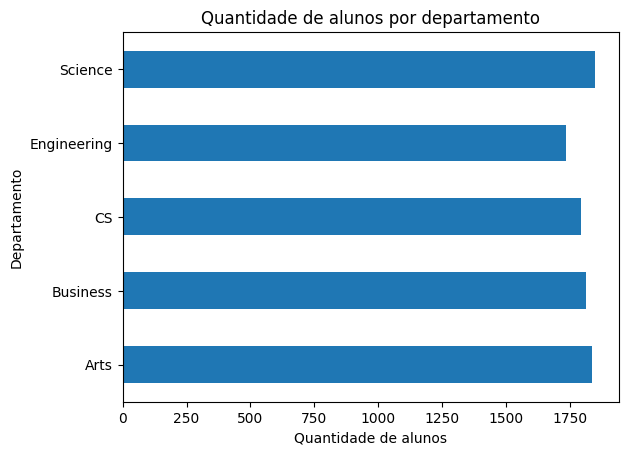

In [291]:
departamentos = df.filter(like='Department_').sum()

departamentos.index = departamentos.index.str.replace('Department_', '')

departamentos.plot(kind='barh')


plt.title('Quantidade de alunos por departamento')
plt.xlabel('Quantidade de alunos')
plt.ylabel('Departamento')

plt.show()


In [292]:
departamentos

Arts           1836
Business       1813
CS             1792
Engineering    1733
Science        1846
dtype: int64

## Há quantos alunos desistentes por departamento?

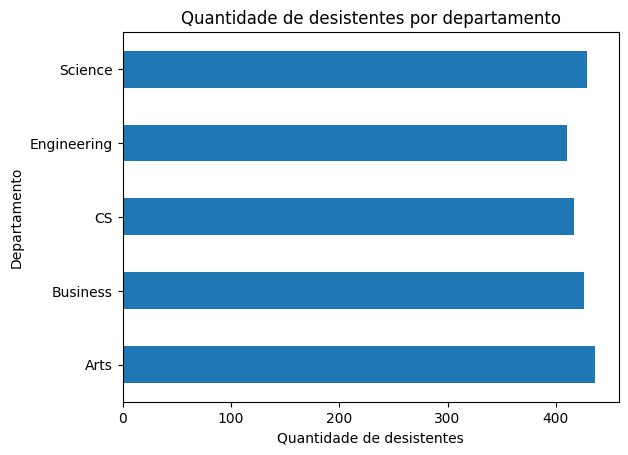

In [293]:
desistentes_departamentos = desistentes.filter(like='Department_').sum()

desistentes_departamentos.index = desistentes_departamentos.index.str.replace('Department_', '')

desistentes_departamentos.plot(kind='barh')

plt.title('Quantidade de desistentes por departamento')
plt.xlabel('Quantidade de desistentes')
plt.ylabel('Departamento')

plt.show()

Observa-se que não relação entre departamentos específicos e taxa de desistência

In [294]:
desistentes_departamentos

Arts           436
Business       426
CS             417
Engineering    410
Science        429
dtype: int64

In [295]:
df['Department_Arts'].value_counts()

Department_Arts
False    7184
True     1836
Name: count, dtype: int64

In [296]:
departamentos_filtrado = df.filter(like='Department_')

In [297]:
resultado = {}

for coluna in departamentos_filtrado.columns:
    dados_dapartamento = df[df[coluna] == 1]
    
    proporcao = dados_dapartamento['Dropout'].value_counts(normalize=True).mul(100).round(2)
    
    resultado[coluna] = proporcao

In [298]:
resultado = pd.DataFrame(resultado).T

In [299]:
# Retirando "Department_" do nome
resultado.index = resultado.index.str.replace('Department_', '')

In [300]:
resultado

Dropout,0,1
Arts,76.25,23.75
Business,76.50,23.50
CS,76.73,23.27
Engineering,76.34,23.66
Science,76.76,23.24


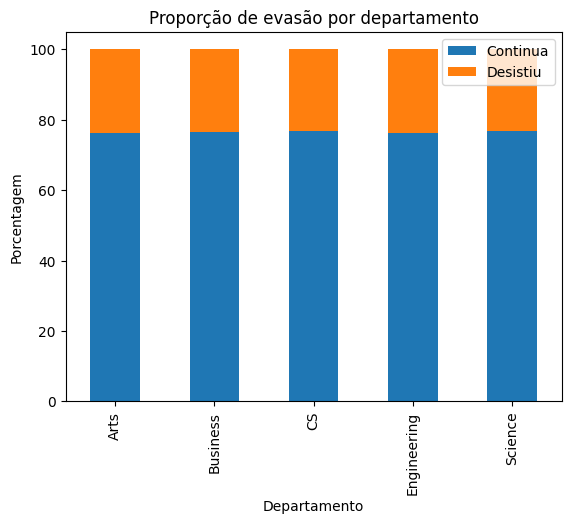

In [302]:
resultado.plot(
    kind='bar',
    stacked=True
)

plt.title('Proporção de evasão por departamento')
plt.xlabel('Departamento')
plt.ylabel('Porcentagem')

plt.legend(['Continua', 'Desistiu'])

plt.show()

O departamento de Artes apresentou a maior taxa de abandono (23,75%), porém os departamentos possuem taxas bastante semelhantes entre si.
Portanto, o departamento aparentemente não exerce grande influência na evasão.